In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
data = {
    "Age": [19, 21, 20, 23, 31, 22, 35, 23, 64, 30],
    "Income": [15, 15, 16, 16, 17, 17, 18, 18, 19, 19],
    "Score": [39, 81, 6, 77, 40, 76, 6, 94, 3, 72]
}

df = pd.DataFrame(data)
df

,Age,Income,Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
5,22,17,76
6,35,18,6
7,23,18,94
8,64,19,3
9,30,19,72


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [6]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

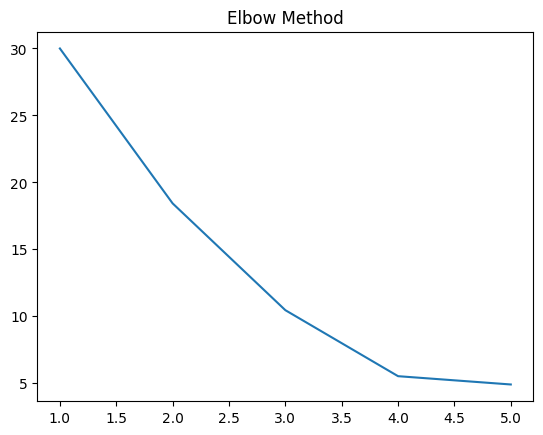

In [7]:
wcss = []

for i in range(1, 6):
    km = KMeans(n_clusters=i)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 6), wcss)
plt.title("Elbow Method")
plt.show()

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

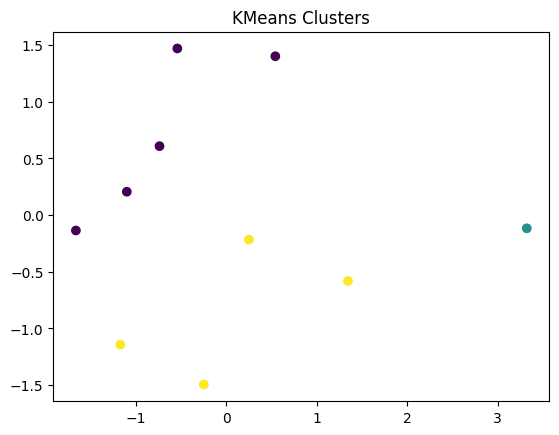

In [9]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("KMeans Clusters")
plt.show()

In [10]:
print("KMeans Silhouette:", silhouette_score(X_scaled, kmeans_labels))
print("Hierarchical Silhouette:", silhouette_score(X_scaled, hc_labels))

KMeans Silhouette: 0.24032082144932274
Hierarchical Silhouette: 0.24032082144932274
